In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score

In [ ]:
data = pd.read_csv('student-por.csv')
data.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
data.shape

(649, 33)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [ ]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
# Checking null values

In [ ]:
missing_data = data.isnull().sum()
missing_data

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [ ]:
# checking an column that are type obj(string,text,categorial data)

In [ ]:
cate_col = data.select_dtypes(include='object').columns
cate_col

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [ ]:
for col in cate_col:
    print(data[col].value_counts())

school
GP    423
MS    226
Name: count, dtype: int64
sex
F    383
M    266
Name: count, dtype: int64
address
U    452
R    197
Name: count, dtype: int64
famsize
GT3    457
LE3    192
Name: count, dtype: int64
Pstatus
T    569
A     80
Name: count, dtype: int64
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64
reason
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64
guardian
mother    455
father    153
other      41
Name: count, dtype: int64
schoolsup
no     581
yes     68
Name: count, dtype: int64
famsup
yes    398
no     251
Name: count, dtype: int64
paid
no     610
yes     39
Name: count, dtype: int64
activities
no     334
yes    315
Name: count, dtype: int64
nursery
yes    521
no     128
Name: count, dtype: int64
higher
yes    580
no      69
Name: count, dtype: int64

In [ ]:
# checking numeric column 

In [ ]:
numeric_col =data.select_dtypes(include=['int64','float64']).columns
numeric_col

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [ ]:
# ploting each numeric col 

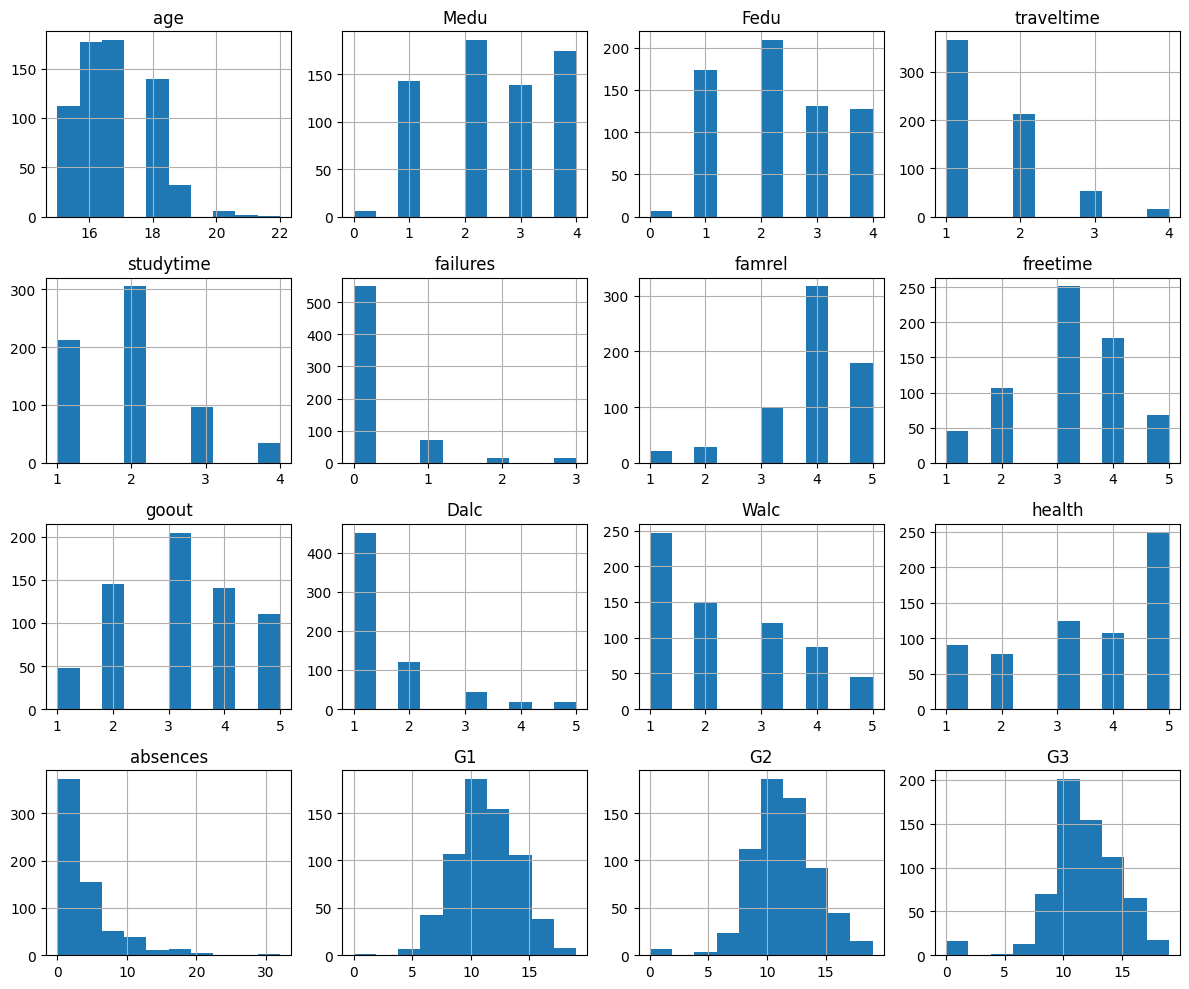

In [ ]:
data[numeric_col].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


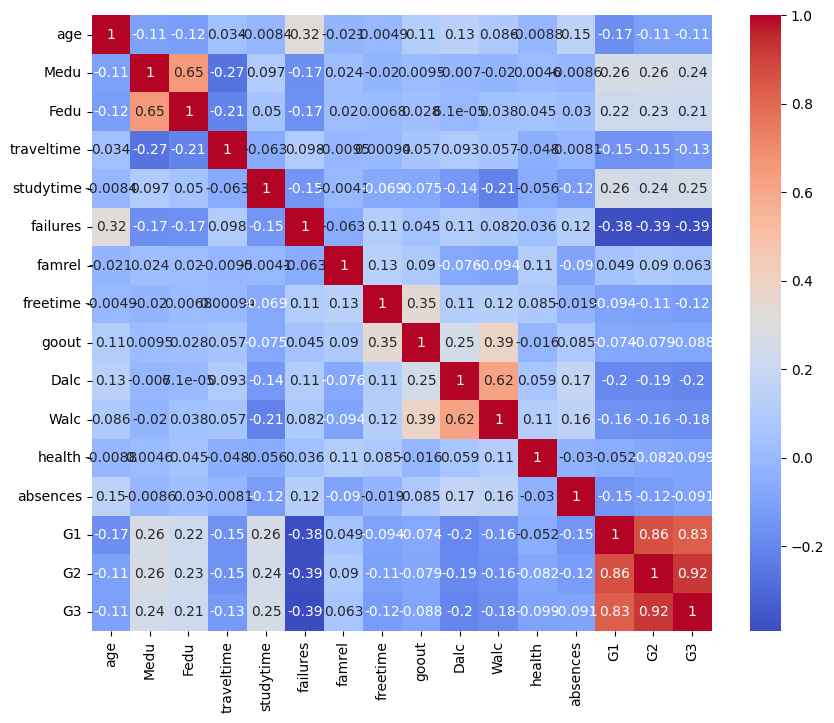

In [ ]:

corr = data[numeric_col].corr()
print(corr['G3'].sort_values(ascending=False))


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [ ]:
# this will encode text/categorical column data to numeric

In [ ]:
data_encoded = pd.get_dummies(data,columns=cate_col,drop_first=True)
data_encoded.columns

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T',
       'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
       'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
       'romantic_yes'],
      dtype='object')

In [ ]:
x = data_encoded.drop('G3',axis=1)
y=data_encoded['G3']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)


In [ ]:
mse


1.4759092563639307

In [ ]:
r2


0.8486513286537315

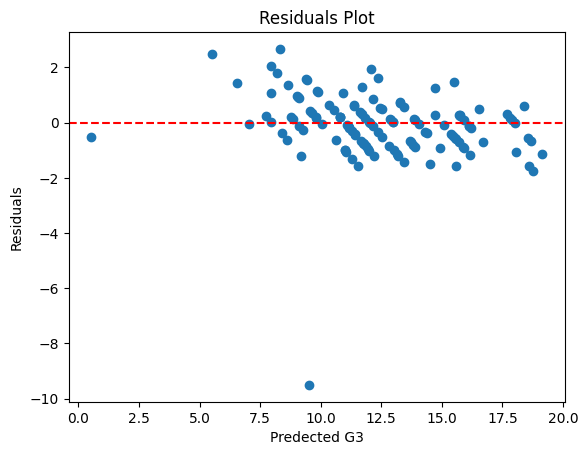

In [ ]:
residuals = y_test-y_pred

plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predected G3")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

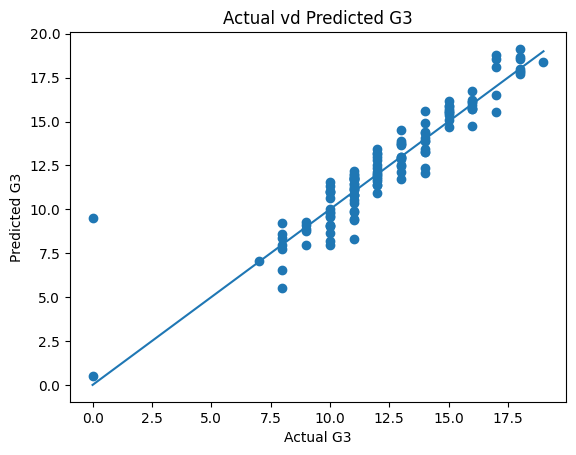

In [ ]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vd Predicted G3")
plt.show()

In [ ]:
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
coefficients.sort_values(by='Coefficient', ascending=False, inplace=True)
print(coefficients)


              Feature  Coefficient
14                 G2     0.858834
20        Mjob_health     0.343000
32     guardian_other     0.322548
23       Mjob_teacher     0.302682
22      Mjob_services     0.259923
13                 G1     0.172172
34         famsup_yes     0.120459
39       internet_yes     0.112868
3          traveltime     0.109541
17          address_U     0.104781
18        famsize_LE3     0.078625
4           studytime     0.061696
40       romantic_yes     0.060722
38         higher_yes     0.050896
2                Fedu     0.038378
10               Walc     0.026934
8               goout     0.017692
12           absences     0.011544
0                 age     0.005962
31    guardian_mother    -0.008693
19          Pstatus_T    -0.023580
36     activities_yes    -0.039472
6              famrel    -0.041749
11             health    -0.055198
37        nursery_yes    -0.060901
9                Dalc    -0.069869
16              sex_M    -0.083599
7            freetim

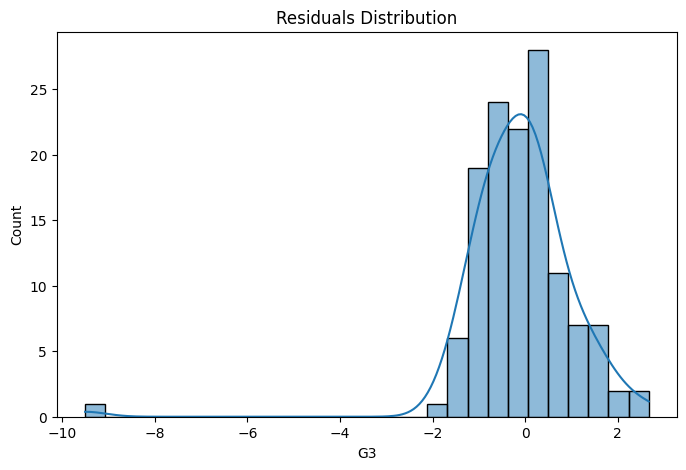

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.show()


In [ ]:
cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')

print("Cross-validated R² scores:", cv_scores)
print("Average R² Score:", cv_scores.mean())

Cross-validated R² scores: [0.75327197 0.7397694  0.82061432 0.8549464  0.80095376]
Average R² Score: 0.7939111706824233


In [ ]:
# predict new data from learning old data

In [ ]:
def predict_grade(new_data):
    df = pd.DataFrame([new_data])
    df = pd.get_dummies(df).reindex(columns=X.columns, fill_value=0)
    return model.predict(df)[0]
